In [ ]:
from sklearn import datasets  # import datasets from sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import sklearn

# from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split

#### the "datasets" in sklearn provides a lot of dataset. one famous dataset is called iris
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [ ]:
iris = datasets.load_iris()  # load iris data from datasets
# print(iris.data)

#### There are 4 features, and 3 classes in the iris dataset

In [ ]:
print(
    "The feature name is", iris.feature_names
)  # feature name includes sepal length, sepal width, petal length, petal width
print(
    "The target name is", iris.target_names
)  # 0 --> setosa, 1 --> versicolor, 2 --> virginica

The feature name is ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
The target name is ['setosa' 'versicolor' 'virginica']


In [ ]:
IsSetosa = (
    iris.target == 0
)  # returns an array of True and False, it is True when target is 0 (setosa)
print("The portion of Setosa is ", IsSetosa.sum() / len(IsSetosa))

The portion of Setosa is  0.3333333333333333


#### The iris dataset is provided by sklearn and is not a pandas.dataframe. In the next cell, we use pd.DataFrame to convert it to a DataFrame that can be handled by pandas

#### We further create a new column "label" to indicate if the sample is setosa or not

In [ ]:
df = pd.DataFrame(
    iris.data
)  # since above codes is for dataframe, we use pandas to change the data into dataframe
df.columns = iris.feature_names  # assign the feature names to the dataframe
df["label"] = (
    IsSetosa  # create a new column in the dataframe called "label" , indicating if the sample is setosa or not
)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,True
1,4.9,3.0,1.4,0.2,True
2,4.7,3.2,1.3,0.2,True
3,4.6,3.1,1.5,0.2,True
4,5.0,3.6,1.4,0.2,True


#### draw all samples in the dataset. If a sample belongs to setosa, it will be 

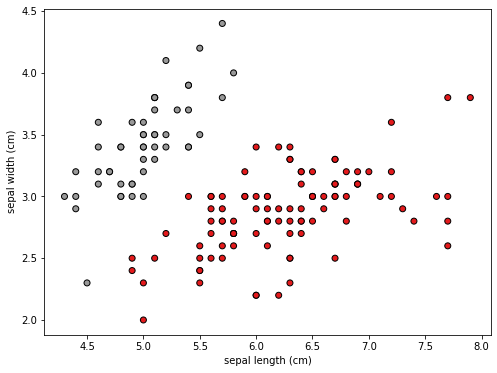

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df.iloc[:, 0], df.iloc[:, 1], c=IsSetosa, cmap=plt.cm.Set1, edgecolor="k"
)  # x axis is sepal length, y axis is sepal width, c is color, when the target is 0, it will gray, and red when the target is not 0
plt.xlabel(
    df.columns[0]
)  # assign column name 'sepal length' to x-axis (python counts from 0)
plt.ylabel(df.columns[1])  # assign column name 'sepal width' to y-axis
plt.show()

In [ ]:
df.isnull().any()  # is there any NAN value?

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
label                False
dtype: bool

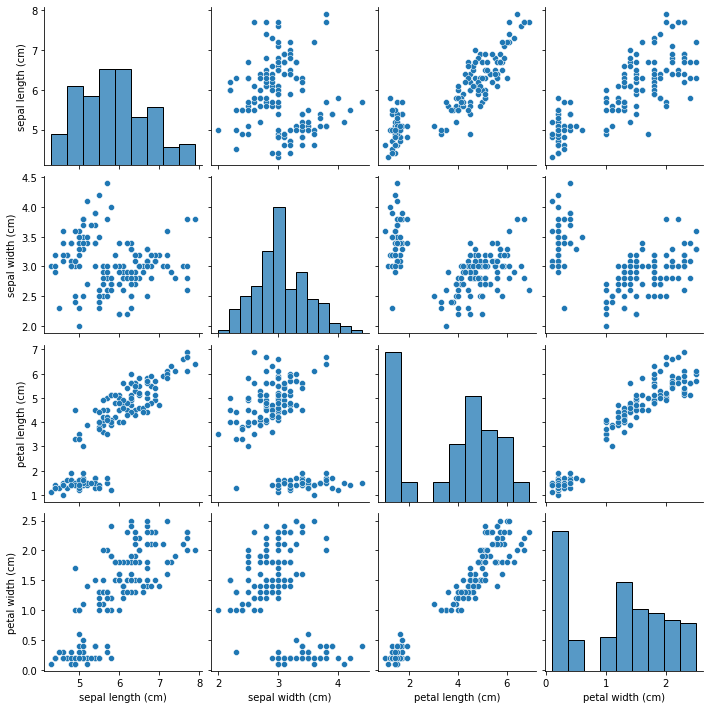

In [ ]:
# Use seaborn to plot pairwise scatter plot
# sns.pairplot(df)
sns.pairplot(df.iloc[:, :-1])
plt.show()

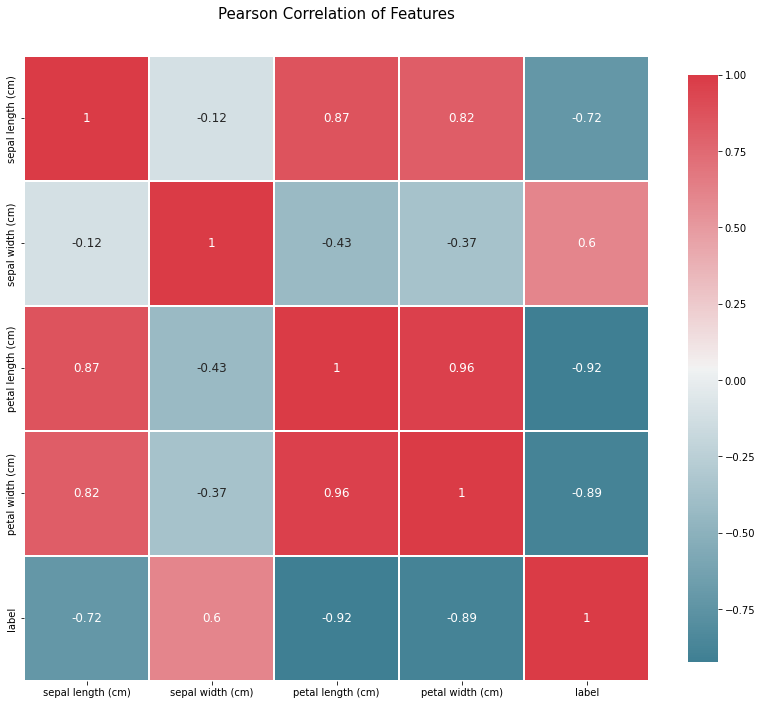

In [ ]:
def correlation_heatmap(data):
    _, ax = plt.subplots(
        figsize=(14, 12)
    )  # Only ax is used in following code, we do not assign value to the other variable
    colormap = sns.diverging_palette(220, 10, as_cmap=True)

    sns.heatmap(
        data.corr(),
        cmap=colormap,
        square=True,
        cbar_kws={"shrink": 0.9},
        ax=ax,
        annot=True,
        linewidths=0.1,
        vmax=1.0,
        linecolor="white",
        annot_kws={"fontsize": 12},
    )

    plt.title("Pearson Correlation of Features", y=1.05, size=15)
    plt.show()


correlation_heatmap(
    df
)  # Input train_df to the function, and check the correlation of all variables

In [ ]:
# split the data into training set and testing set, and set seed = 0
train, test = train_test_split(df, test_size=0.1, random_state=0)
print("Size of the train dataset is ", train.shape)
print("Size of the test dataset is ", test.shape)

Size of the train dataset is  (135, 5)
Size of the test dataset is  (15, 5)


In [ ]:
# Let x in the training set be the variable without Murder
# Let y in the training set be Murder
x_train = train.iloc[:, :-1]

# Let x in the testing set be the variable without Murder
# Let y in the testing set be Murder
y_train = train["label"]
x_test = test.iloc[:, :-1]
y_test = test["label"]

#### fit the logistic regression using the training dataset

In [ ]:
from sklearn import linear_model

logreg = linear_model.LogisticRegression(
    C=1
)  # C is an inverse regularization parameter controlling overfitting, a smaller C specify stronger regularization
logreg.fit(x_train.iloc[:, 0:2], y_train)

LogisticRegression(C=1)

#### Visualize the decision boundary

The generated points are:  [4.         4.33333333 4.66666667 5.         5.33333333 5.66666667
 6.         6.33333333 6.66666667 7.        ]
The estimated decision boundary is: [1.66106122 2.01530613 2.36955104 2.72379595 3.07804086 3.43228576
 3.78653067 4.14077558 4.49502049 4.84926539]


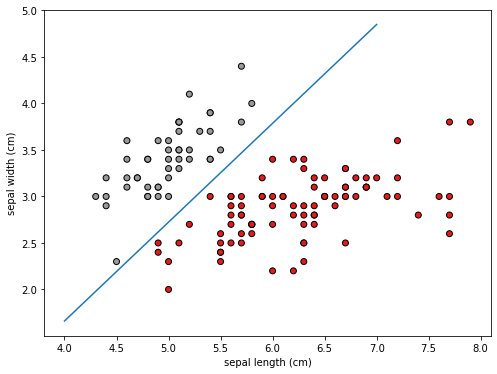

In [ ]:
# plot training data and the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(
    x_train.iloc[:, 0], x_train.iloc[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolor="k"
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

Xii = np.linspace(4, 7, 10)  # equally spaced 10 points from 4 to 7
print("The generated points are: ", Xii)
Yii = (-logreg.coef_[0][0] * Xii - logreg.intercept_) / logreg.coef_[0][
    1
]  # let 1/(1+exp(wx)) = 1/2, exp(wx)=1, wx = 0, we can have this equation
print("The estimated decision boundary is:", Yii)
plt.plot(Xii, Yii)

plt.show()

#### visualize the performance of the trained model on the testing dataset 

The generated points are:  [4.         4.33333333 4.66666667 5.         5.33333333 5.66666667
 6.         6.33333333 6.66666667 7.        ]
The estimated decision boundary is: [1.66106122 2.01530613 2.36955104 2.72379595 3.07804086 3.43228576
 3.78653067 4.14077558 4.49502049 4.84926539]


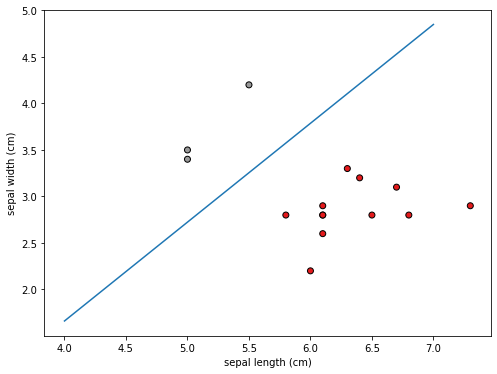

In [ ]:
# plot the test data and the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(
    x_test.iloc[:, 0], x_test.iloc[:, 1], c=y_test, cmap=plt.cm.Set1, edgecolor="k"
)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

Xii = np.linspace(4, 7, 10)  # equally spaced 10 points from 4 to 7
print("The generated points are: ", Xii)
Yii = (-logreg.coef_[0][0] * Xii - logreg.intercept_) / logreg.coef_[0][
    1
]  # let 1/(1+exp(wx)) = 1/2, exp(wx)=1, wx = 0, we can have this equation
print("The estimated decision boundary is:", Yii)
plt.plot(Xii, Yii)

plt.show()

In [ ]:
print("The model coefficients are")
print(
    "w_0=",
    logreg.intercept_[0],
    "; w_1=",
    logreg.coef_[0][0],
    "; w_2=",
    logreg.coef_[0][1],
)

The model coefficients are
w_0= 8.023037378500241 ; w_1= -3.2921865430057586 ; w_2= 3.0978441479252723


#### ".predict()" provides the predicted class. In next cell, we collect the ground-truth class and the predicted class, and compare them

In [ ]:
y_pred = logreg.predict(x_test.iloc[:, 0:2])  # predict based on pedal width and length
compare = pd.DataFrame(
    {"predict": y_pred, "true": y_test}
)  # use dictionary to construct dataframe, compares the true label and predicte label
compare

,predict,true
114,False,False
62,False,False
33,True,True
107,False,False
7,True,True
100,False,False
40,True,True
86,False,False
76,False,False
71,False,False


#### We have learnt the $r^2$ and adjusted $r^2$ in linear regression. But it is for evaluating the regression. Here the problem is about classification.

#### sklearn.metrics provides a lot of evaluation function for different machine learning problems

#### We can use the 'accuracy_score' function in the metrics to help us to calculate the accuracy for binary classification

In [ ]:
from sklearn.metrics import accuracy_score

print(
    "The prediction accuracy is:", accuracy_score(y_test, y_pred)
)  # check the accuracy, it shows that the prediction accuracy is 100%

The prediction accuracy is: 1.0
